<a href="https://colab.research.google.com/github/AlinaUK/Alina_Business_Card/blob/main/Analytic_Tools_Class_7_Questions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Class 7 exercises.

**Answer the following questions using Python programming language and the slides of class 7.**

# **PART 1: Cross validation with scikit**

**Question 1:** Let us load from the library the iris dataset and create the X and y variables.

Iris dataset is very common in data science, so scikit provides Iris data as a library.

In [3]:
# import random search, random forest, iris data, and distributions
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier

# get iris data
iris = datasets.load_iris()

# The Iris library provides data (features) and target variables
X = iris.data
y = iris.target

**Question 2:** Here I initialize a KNN classifier and feed it to sklearn’s cross_validate function. This function receives a model, its training data, the array or dataframe column of target values, and the number of folds for it to cross validate over (the number of models it will train).

The cross validation object stores the out of sample accuracy of each of its trained models. Taking the average of these K out-of-sample scores gives you the model’s cross-validation accuracy, a low-variance estimate of how the model will perform on unseen data.

In [4]:
from sklearn.model_selection import cross_validate

model = KNeighborsClassifier(n_neighbors=3)
cv1 = cross_validate(model, X, y, cv=5)
print(cv1)

print(cv1['test_score'])

{'fit_time': array([0.00516582, 0.00108457, 0.00096607, 0.00103736, 0.00093269]), 'score_time': array([0.00747132, 0.00382495, 0.00352931, 0.00365186, 0.00344563]), 'test_score': array([0.96666667, 0.96666667, 0.93333333, 0.96666667, 1.        ])}
[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]


**Question 3.1:** Can you print the *mean* of the cross validation scores? This will be the accuracy of our model.

In [5]:
# Provide your solution
print(cv1['test_score'].mean())


0.9666666666666668


**Question 3.2:** Let us try the next code, it will create a new train test split setup for our KNN classifier.

* The random state is 22, and it ensures that each run shows the same result.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=22)

from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9736842105263158

**Question 4:** Let us try to remove the random state, this means that **results will be always random**.

Run the next code multiple times, you might notice that the accuracy varies according to the selection of data.

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75)

from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

1.0

**Question 5.1:** Let us try to use the cross validation, in this case we need to import the **cross_validate** and then decide the cross validation folds (e.g. 5).

Study and run the following.

In [8]:
from sklearn.model_selection import cross_validate

cv1 = cross_validate(clf, X, y, cv=5)
print(cv1['test_score'].mean())

0.9666666666666668


**Question 5.2:** Can you print the cross validation score for 10 folds?

In [9]:
# Provide your solution here
cv1 = cross_validate(clf, X, y, cv = 10)
print(cv1['test_score'].mean())


0.9666666666666666


**Question 6:** Let us try to see the accuracy score using different fold numbers (e.g. from 2 to 20).

In [10]:
for i in range(2,20):
  cv1 = cross_validate(clf, X, y, cv=i)
  print(cv1['test_score'].mean())

0.94
0.9733333333333333
0.9599928876244666
0.9666666666666668
0.9666666666666667
0.9669140383426098
0.9671052631578947
0.960375816993464
0.9666666666666666
0.9605394605394605
0.9674145299145299
0.9673659673659672
0.9610389610389609
0.9600000000000001
0.9666666666666666
0.9673202614379084
0.9591049382716049
0.9605263157894737


<img src='https://drive.google.com/uc?id=1zHRUx7gL2e5LMUMQ1_zPt6V0MI-v5Iv5' width="50" height="50">  

>**Observation** It seems that with cross validation our results converge to accuracy score of 0.96.

# **PART 2: Decision Trees with scikit learn**

**Question 1:** Load the *Iris.csv* file in the Colab and *read* it as a dataframe.

In [11]:
# Provide your solution here
import pandas as pd

iris_data = pd.read_csv('Iris.csv')
iris_data


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


**Question 2:** Print the firts 4 rows of your dataframe.


In [12]:
# Provide your solution here
iris_data.loc[0:3]


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa


**Question 3:** Let us proceed with our analysis. We will need to split our dataset into independent data **(X)** and dependent data **(y)**. As discussed in class, the independent data is the data that our machine learning model will *learn* from in order to predict the dependent variable.

We will use the sepal width, and the petal length and width to predict the sepal.length. In this case, we can skip the variety column in our model.


So, the independent data is:
*  sepal.width
*  petal.length
*  petal.width

The dependent data is:
*  sepal.length

Extract the data for the dependent variables (and assiciated columns) and store it in a new dataframe called *iris_data_independent_data*. This will be the **X** variable.


In [13]:
# Provide your solution here
iris_data_independent_data = iris_data[['sepal.width', 'petal.length','petal.width']]
iris_data_dependent_data = iris_data[['sepal.length']]

X = iris_data_independent_data
y = iris_data_dependent_data

X
y


,sepal.length
0,5.1
1,4.9
2,4.7
3,4.6
4,5.0
...,...
145,6.7
146,6.3
147,6.5
148,6.2


**Question 4:** Let's create a new **Decision Tree regressor**.
Fit the X and y variables.

You may try
```Python
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(X,y)
```


In [14]:
# Provide your solution here
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(X,y)


DecisionTreeRegressor()

**Question 5:** Use the decision tree regressor to predict sepal.length with the following data:
* 3.1, 1.5, 0.2

Note that the actual value is 4.6.

In [15]:
# Provide your solution here
dtr.predict([[3.1, 1.5, 0.2]])


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([4.75])

**Question 6:** Run the following code, this script will download and install the required libraries for ploting a decision tree.

In [16]:
!pip install pydotplus

**Question 7:** Run the followin script. The script downloads the iris dataset from sklearn datasets and visualises the decision tree.

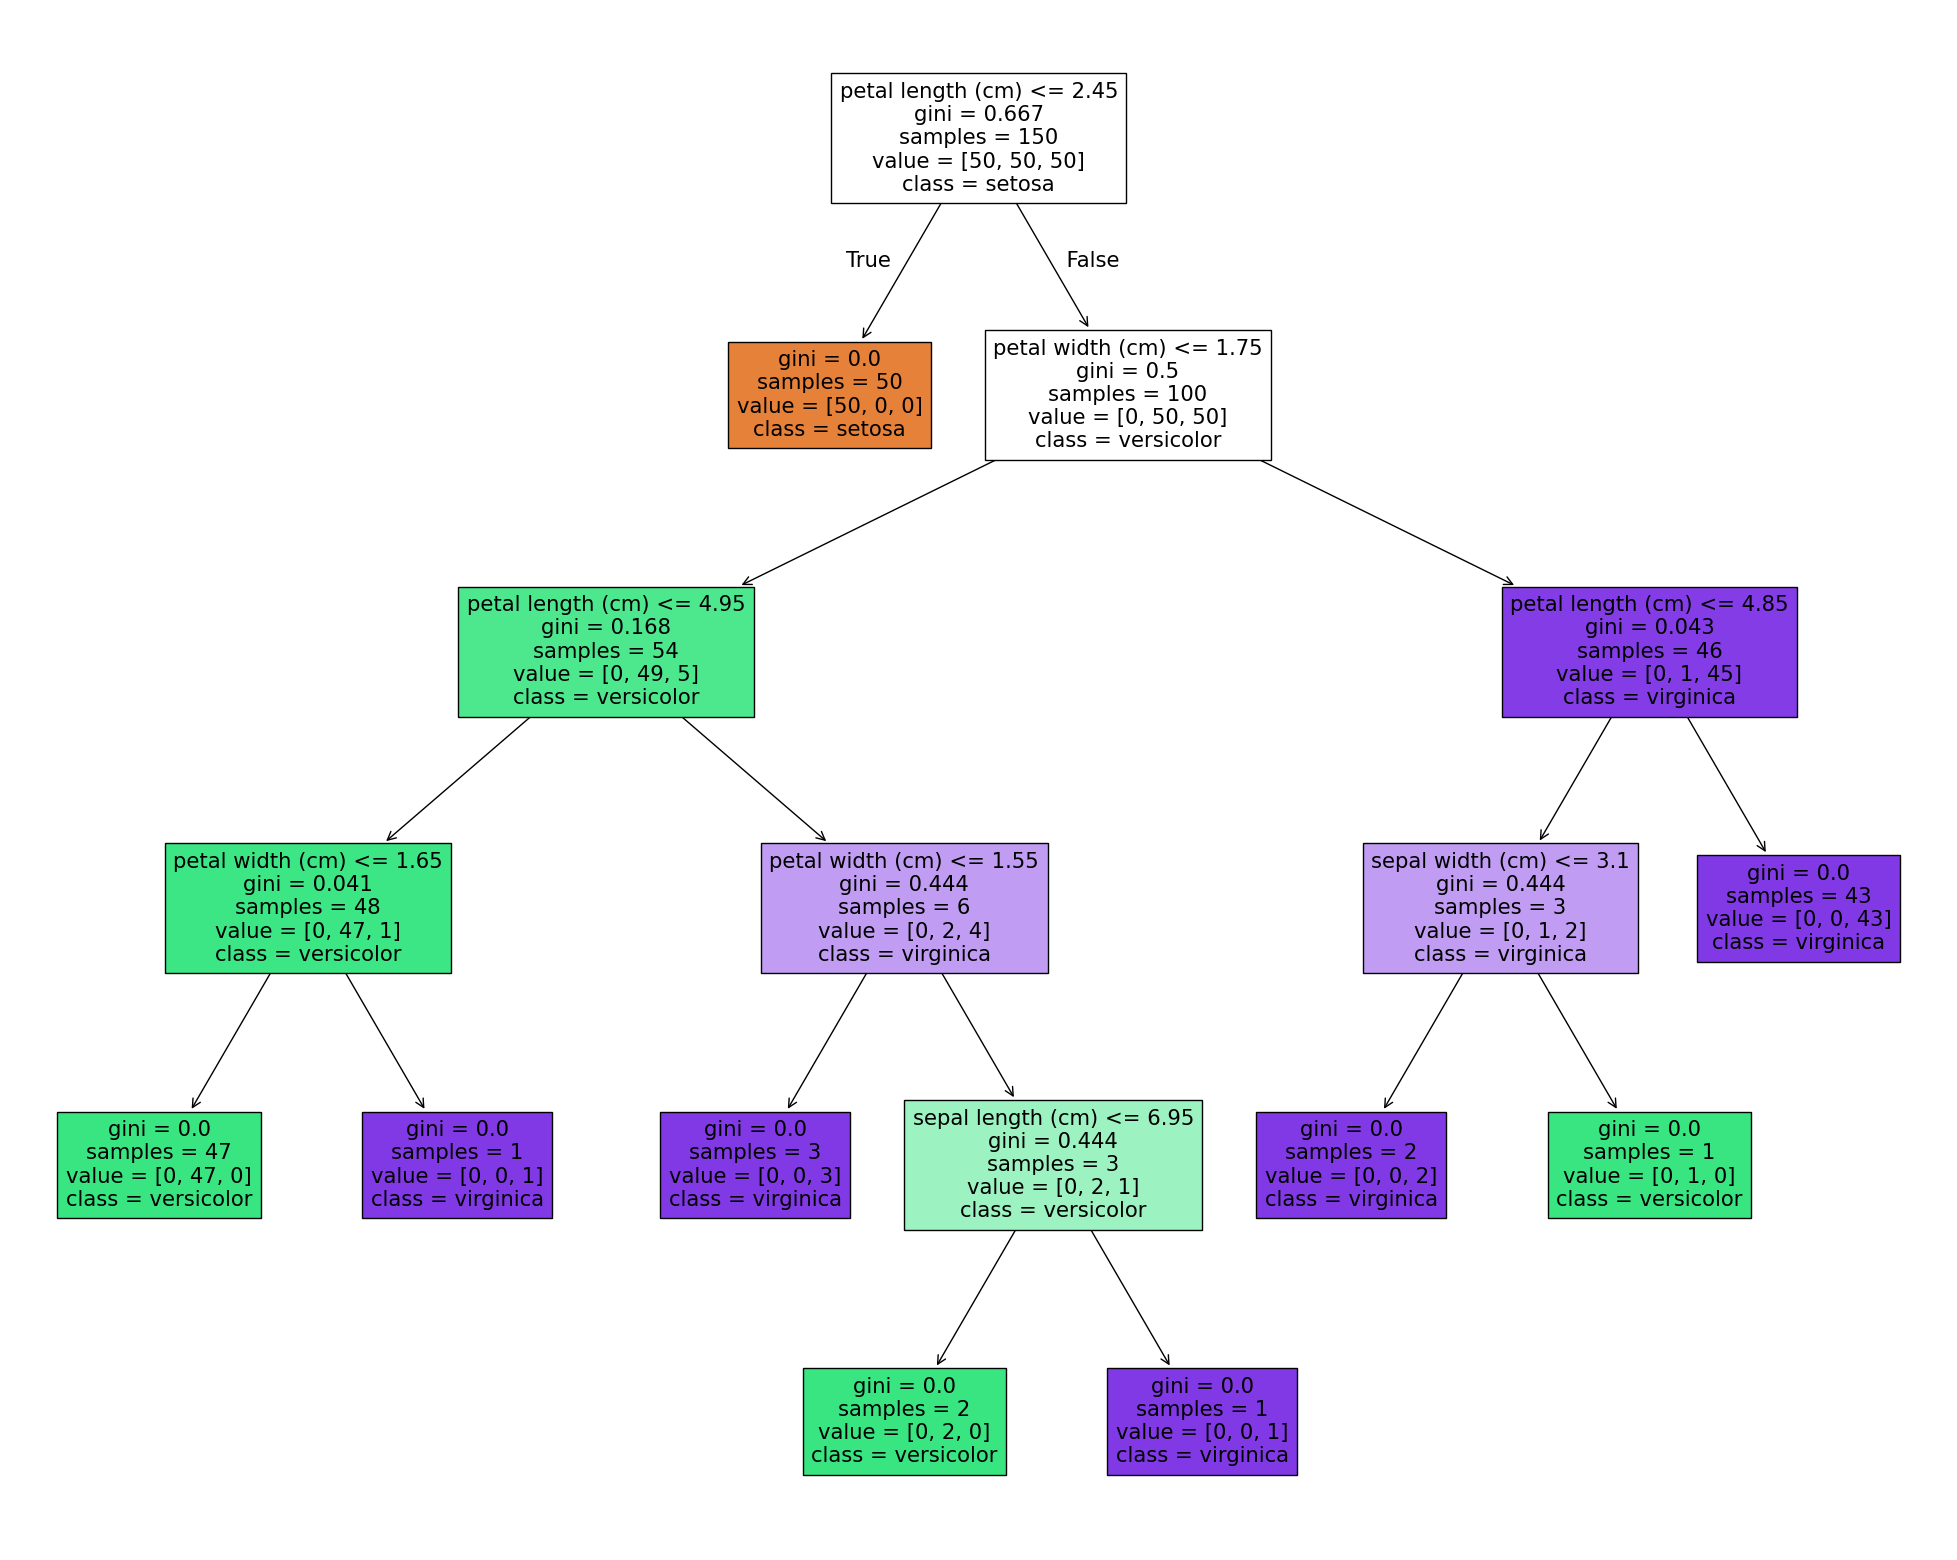

In [17]:
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
# Prepare the data data
iris = datasets.load_iris()
X = iris.data
y = iris.target
# Fit the classifier with default hyper-parameters
clf = DecisionTreeClassifier(random_state=1234)
model = clf.fit(X, y)

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(clf,
                   feature_names=iris.feature_names,
                   class_names=iris.target_names,
                   filled=True)

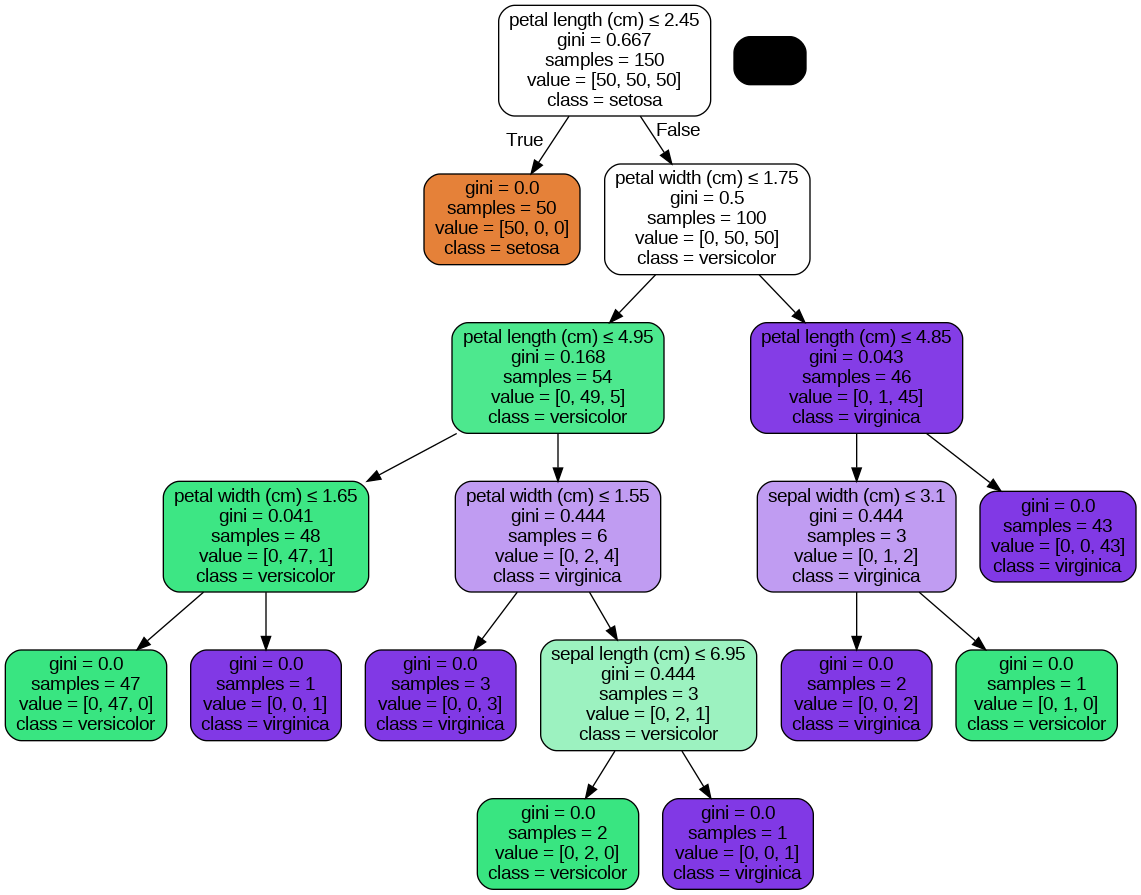

In [18]:
from sklearn.tree import export_graphviz
# from sklearn.externals.six import StringIO
from six import StringIO

from IPython.display import Image
import pydotplus

from sklearn.datasets import load_iris
data = load_iris()
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,feature_names = data.feature_names,class_names=data.target_names)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

# **PART 3: Unsupervised learning**

**Question 1:** We will use the scikit-learn library in Python to load the Iris dataset and matplotlib for data visualization.

We do not need to load the file, sklearn provides the datasets for us, we can simply import it.

Study and run the following.


In [19]:
# Importing Modules
from sklearn import datasets
import matplotlib.pyplot as plt

# Loading dataset
iris_df = datasets.load_iris()

iris_df

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

**Question 2:** We will explore the available methods provided by the default dataset (of scikit).
We have a description, feature names, target names etc. These are all the variables we need.
Since these are all provided we dont have to create the X and the y.

Study and run the following.


In [20]:
# Available methods on dataset

print(dir(iris_df))

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


**Question 3:** Let's print the feature names, targets and target names.

Study and run the following.

In [21]:
# Features
print(iris_df.feature_names)

# Targets
print(iris_df.target)

# Target Names
print(iris_df.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


**Question 4:** Let's plot the sepal lenght and sepal width variables, but let's assume that we don't know the classes.

Study and run the following.

It seems that there are some clusters!

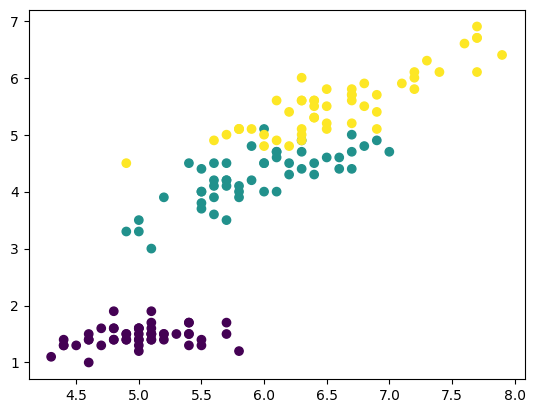

In [22]:
# Dataset Slicing
x_axis = iris_df.data[:, 0]  # Sepal Length
y_axis = iris_df.data[:, 2]  # Sepal Width

# Plotting
plt.scatter(x_axis, y_axis, c=iris_df.target)
plt.show()

**Question 5:** Let's create a  K-means clustering algorithm and use our dataset. It seems that there are three classes, so I will use k=3.
Study and run the following.

In [23]:
# Importing Modules
from sklearn.cluster import KMeans

# Declaring Model
model = KMeans(n_clusters=3)

# Fitting Model
model.fit(iris_df.data)

# Predicitng a single input
predicted_label = model.predict([[7.2, 3.5, 0.8, 1.6]])
print(predicted_label)

[0]


**Question 6:** Let's plot a 3D diagram to explore the centroids between petal width, petal lenght and sepal length.

Do not worry about the details of this cose. Study and run the following.

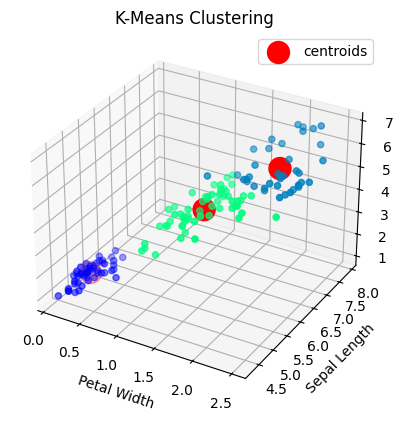

In [24]:
# Imports
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load Data
iris = load_iris()

# Create a dataframe
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['target'] = iris.target
X = iris.data
df.sample(4)

# Instantiate Kmeans
km = KMeans(3)
clusts = km.fit_predict(X)

#Plot the clusters obtained using k means
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(km.cluster_centers_[:, 3],
            km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 2],
            s = 250,
            marker='o',
            c='red',
            label='centroids')
scatter = ax.scatter(df['petal width (cm)'],df['sepal length (cm)'], df['petal length (cm)'],
                     c=clusts,s=20, cmap='winter')


ax.set_title('K-Means Clustering')
ax.set_xlabel('Petal Width')
ax.set_ylabel('Sepal Length')
ax.set_zlabel('Petal Length')
ax.legend()
plt.show()

**Question 7:** Let us assume some random data. Study and run the following.

In [25]:
import numpy as np
X = np.array([[5,3],
     [10,15],
     [15,12],
     [24,10],
     [30,45],
     [85,70],
     [71,80],
     [60,78],
     [55,52],
     [80,91],])

**Question 8:** Plot the data and examine the possible cluster. Study and run the following.

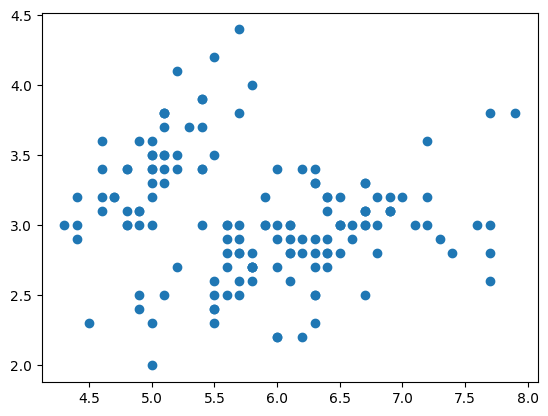

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.cluster import KMeans

plt.scatter(X[:,0],X[:,1], label='True Position')

**Question 9:** Create a new k-means clustering model using 2 clusters.

In [28]:
# Provide your solution here
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)


KMeans(n_clusters=2)

**Question 10:** Plot the points. It seems that there are two clusters. Study and run the following.

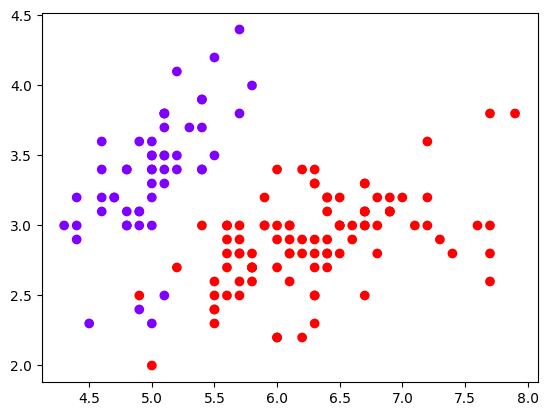

In [30]:
plt.scatter(X[:,0],X[:,1], c=kmeans.labels_, cmap='rainbow')

**Question 11:** Create a new k-means clustering model and plot a diagram with three clusters.

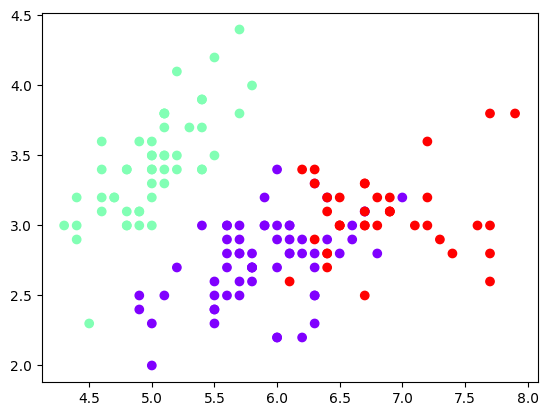

In [31]:
# Provide your solution here

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
plt.scatter(X[:,0],X[:,1], c=kmeans.labels_, cmap='rainbow')


# **EXTRA with the Covid example**


This is an example of the Covid data.

In [33]:

# https://coronavirus.data.gov.uk/details/vaccinations
import pandas as pd

vaccine_data = pd.read_csv('data_2022-Jan-31.csv')
vaccine_data.head()


,areaType,areaName,areaCode,date,newPeopleVaccinatedFirstDoseByPublishDate,cumPeopleVaccinatedFirstDoseByPublishDate
0,overview,United Kingdom,K02000001,2022-01-30,11684.0,52345158
1,overview,United Kingdom,K02000001,2022-01-29,18946.0,52333474
2,overview,United Kingdom,K02000001,2022-01-28,16949.0,52314528
3,overview,United Kingdom,K02000001,2022-01-27,15706.0,52297579
4,overview,United Kingdom,K02000001,2022-01-26,15358.0,52281873


In [35]:
vaccine_data['new date'] =  pd.to_datetime(vaccine_data['date'])

In [36]:
X = vaccine_data[['cumPeopleVaccinatedFirstDoseByPublishDate']]
y = vaccine_data['new date']

In [37]:
vaccine_data.head()

,areaType,areaName,areaCode,date,newPeopleVaccinatedFirstDoseByPublishDate,cumPeopleVaccinatedFirstDoseByPublishDate,new date
0,overview,United Kingdom,K02000001,2022-01-30,11684.0,52345158,2022-01-30
1,overview,United Kingdom,K02000001,2022-01-29,18946.0,52333474,2022-01-29
2,overview,United Kingdom,K02000001,2022-01-28,16949.0,52314528,2022-01-28
3,overview,United Kingdom,K02000001,2022-01-27,15706.0,52297579,2022-01-27
4,overview,United Kingdom,K02000001,2022-01-26,15358.0,52281873,2022-01-26


In [38]:
import pandas as pd

# Matplotlib for additional customization
from matplotlib import pyplot as plt
%matplotlib inline

# Seaborn for plotting and styling
import seaborn as sns

print("Matplotlib and Seaborn are imported")

Matplotlib and Seaborn are imported


In [39]:
vaccine_data = vaccine_data.sort_values(by=['cumPeopleVaccinatedFirstDoseByPublishDate'])

<Axes: xlabel='date', ylabel='cumPeopleVaccinatedFirstDoseByPublishDate'>

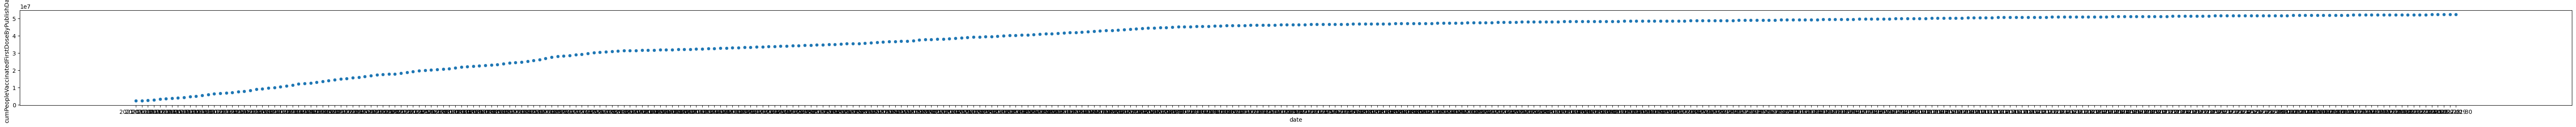

In [40]:
# Study and run the following code
plt.rcParams["figure.figsize"] = (80,3)
sns.scatterplot(x='date', y='cumPeopleVaccinatedFirstDoseByPublishDate',data=vaccine_data)

In [42]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X, y)


In [43]:
# UK population 66.65 million (2019)

n=reg.predict([[66650000]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [44]:
pd.to_datetime(n, unit='ns')

DatetimeIndex(['2022-02-04 23:18:13.923534080'], dtype='datetime64[ns]', freq=None)